# Datos Faltantes

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [3]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [4]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
411,0.005383,-0.044642,0.058463,-0.043542,-0.073119,-0.072399,0.019187,-0.076395,-0.051404,-0.025930,136.0
74,0.012648,0.050680,0.002417,0.056301,0.027326,0.017162,0.041277,-0.039493,0.003709,0.073480,85.0
429,-0.041840,-0.044642,-0.033151,-0.022885,0.046589,0.041587,0.056003,-0.024733,-0.025953,-0.038357,94.0
83,-0.038207,-0.044642,0.009961,-0.046985,-0.059359,-0.052983,-0.010266,-0.039493,-0.015999,-0.042499,210.0
120,-0.049105,-0.044642,0.004572,0.011544,-0.037344,-0.018537,-0.017629,-0.002592,-0.039809,-0.021788,200.0
37,-0.009147,-0.044642,0.011039,-0.057313,-0.024960,-0.042963,0.030232,-0.039493,0.017036,-0.005220,276.0
210,0.009016,-0.044642,0.014272,0.014987,0.054845,0.047224,0.070730,-0.039493,-0.033246,-0.059067,191.0
276,0.012648,-0.044642,0.026128,0.063187,0.125019,0.091691,0.063367,-0.002592,0.057573,-0.021788,283.0
154,0.067136,0.050680,0.020739,-0.005670,0.020446,0.026243,-0.002903,-0.002592,0.008641,0.003064,197.0
360,0.016281,-0.044642,0.020739,0.021872,-0.013953,-0.013214,-0.006584,-0.002592,0.013317,0.040343,281.0


In [5]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [6]:
data.isnull().sum()

age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64

### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [7]:
imputer = SimpleImputer(strategy='mean')

data[['bmi']] = imputer.fit_transform(data[['bmi']])

In [8]:
data['bmi'].isnull().sum()

np.int64(0)

### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [9]:
knn_imputer = KNNImputer(n_neighbors=5)

data[['bmi', 'bp']] = knn_imputer.fit_transform(data[['bmi', 'bp']])

data[['bmi', 'bp']].head(10)

,bmi,bp
0,0.061696,0.021872
1,-0.051474,0.003970
2,0.044451,-0.005670
3,-0.011595,-0.036656
4,-0.036385,0.021872
5,-0.040696,-0.019442
6,-0.047163,-0.015999
7,-0.001895,0.066629
8,0.061696,-0.040099
9,-0.000205,-0.033213


In [10]:
data[['bmi', 'bp']].isnull().sum()

bmi    0
bp     0
dtype: int64

### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

NameError: name 'data_knn' is not defined

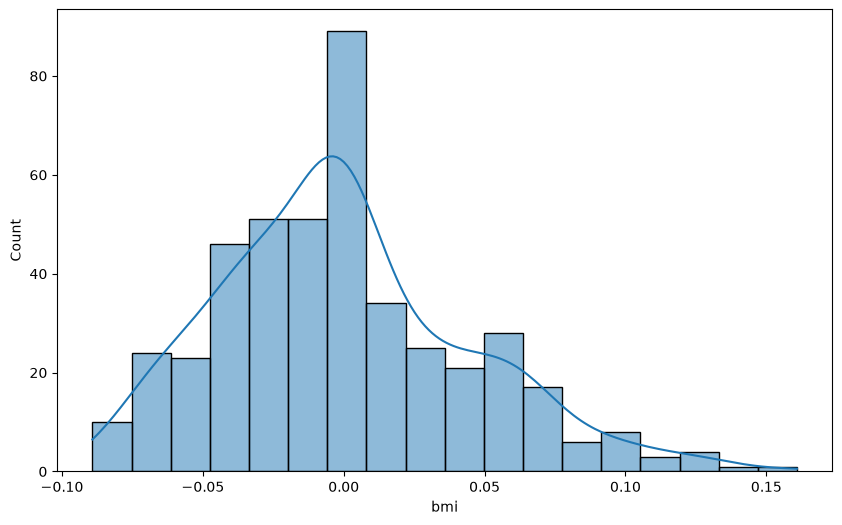

In [11]:
plt.figure(figsize=(10, 6))

sns.histplot(data['bmi'], label='Antes de la imputación', kde=True)
sns.histplot(data_knn['bmi'], label='Después de la imputación KNN', kde=True)

plt.title('Comparación de BMI antes y después de la imputación')
plt.xlabel('BMI')
plt.ylabel('Frecuencia')
plt.legend()

plt.show()